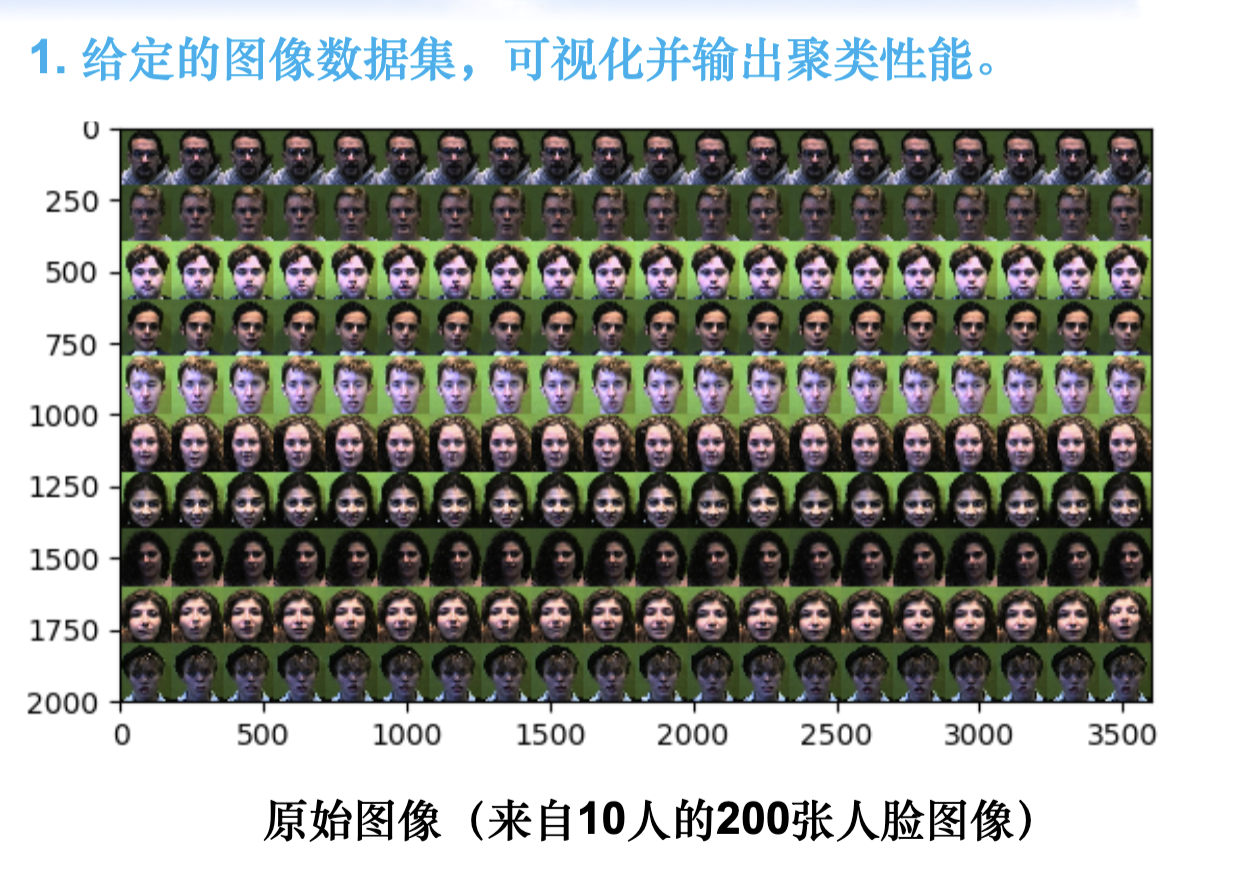

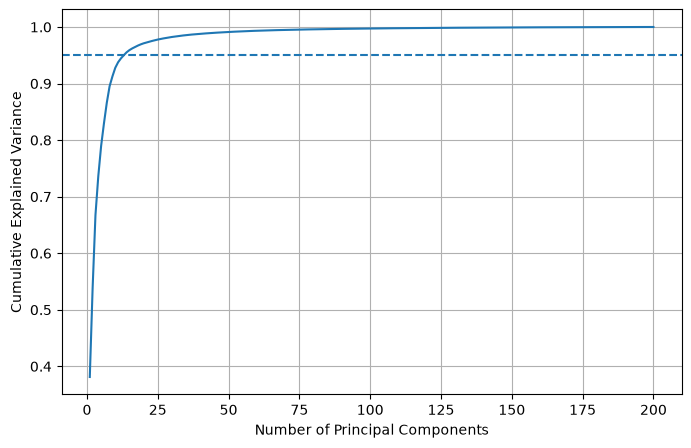

In [72]:
import os
import matplotlib.pyplot as plt
import numpy as np
data_dir = "/Users/caijingxi/Desktop/FZU_2026_Autumn/机器学习/第04次作业/face_images"

person_names = []

#检查读取资料架
for name in os.listdir(data_dir):

    path = os.path.join(data_dir, name)

    if os.path.isdir(path):
        person_names.append(name)

person_names = sorted(person_names)

# print(person_names)
# print("人数：", len(person_names))


#确认读取照片尺寸
import matplotlib.pyplot as plt

person = person_names[0]

folder = os.path.join(data_dir, person)

files = sorted(os.listdir(folder))

# print(files[:5])
img_path = os.path.join(folder, files[0])

img = plt.imread(img_path)

# print(img.shape)

# plt.imshow(img)
# plt.show()

#读取全部图片
images = []
labels = []

for label, person in enumerate(person_names):

    folder = os.path.join(data_dir, person)

    for file in sorted(os.listdir(folder)):

        if file.endswith(".jpg"):

            img_path = os.path.join(folder, file)

            img = plt.imread(img_path)

            images.append(img)

            labels.append(label)
            
images = np.array(images)
y = np.array(labels)

#print("images shape:", images.shape)
#print("y shape:", y.shape)


# print("原始 shape:", images.shape)

X = np.array(images)
X = X.reshape(X.shape[0], -1)

# print("展开后 shape:", X.shape)

X = X.astype("float64")

if X.max() > 1:
    X = X / 255.0
    
# print("X shape:", X.shape)
# print("最小值:", X.min())
# print("最大值:", X.max())

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X)

# print("PCA 前:", X.shape)
# print("PCA 后:", X_pca.shape)

# print(pca.explained_variance_ratio_[:10])

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# print(cumulative_variance[:20])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.grid()

plt.show()

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

# print(
#     "保留 95% 方差需要的主成分数量:",
#     n_components_95
# )

pca_95 = PCA(
    n_components=0.95
)

X_pca_95 = pca_95.fit_transform(X)

原始数据: (200, 108000)
PCA 数据: (200, 13)
累计解释率: 0.9500923506307888


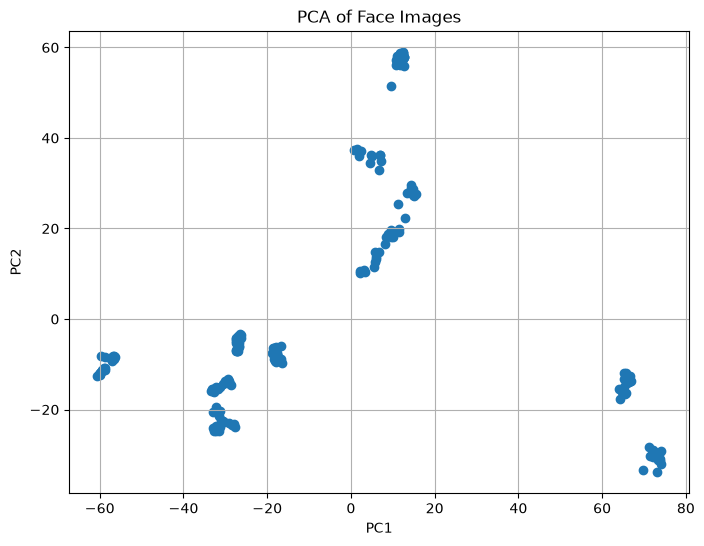

In [73]:
print("原始数据:", X.shape)
print("PCA 数据:", X_pca_95.shape)

print(
    "累计解释率:",
    pca_95.explained_variance_ratio_.sum()
)

pc1 = X_pca_95[:, 0]
pc2 = X_pca_95[:, 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    pc1,
    pc2
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Face Images")

plt.grid()

plt.show()

In [74]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.optimize import linear_sum_assignment
import numpy as np

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=20
)

kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=20
)

def cluster_acc(true_label, pred_label):

    true_label = np.asarray(true_label)
    pred_label = np.asarray(pred_label)

    D = max(true_label.max(), pred_label.max()) + 1

    w = np.zeros((D, D), dtype=np.int64)

    for i in range(pred_label.size):
        w[pred_label[i], true_label[i]] += 1

    row_ind, col_ind = linear_sum_assignment(
        w.max() - w
    )

    return w[row_ind, col_ind].sum() / pred_label.size

ACC = cluster_acc(labels, y_pred)

NMI = metrics.normalized_mutual_info_score(
    labels,
    y_pred
)

ARI = metrics.adjusted_rand_score(
    labels,
    y_pred
)

print("ACC =", ACC)
print("NMI =", NMI)
print("ARI =", ARI)



ACC = 1.0
NMI = 1.0
ARI = 1.0


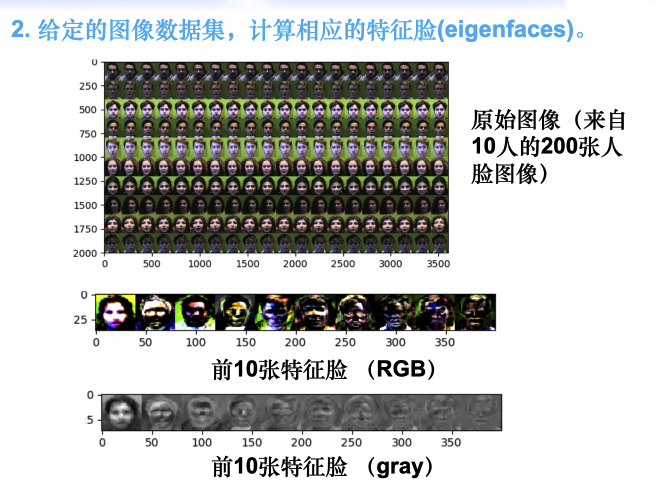

单张图片 shape: (200, 180, 3)
特征脸 shape: (13, 200, 180, 3)


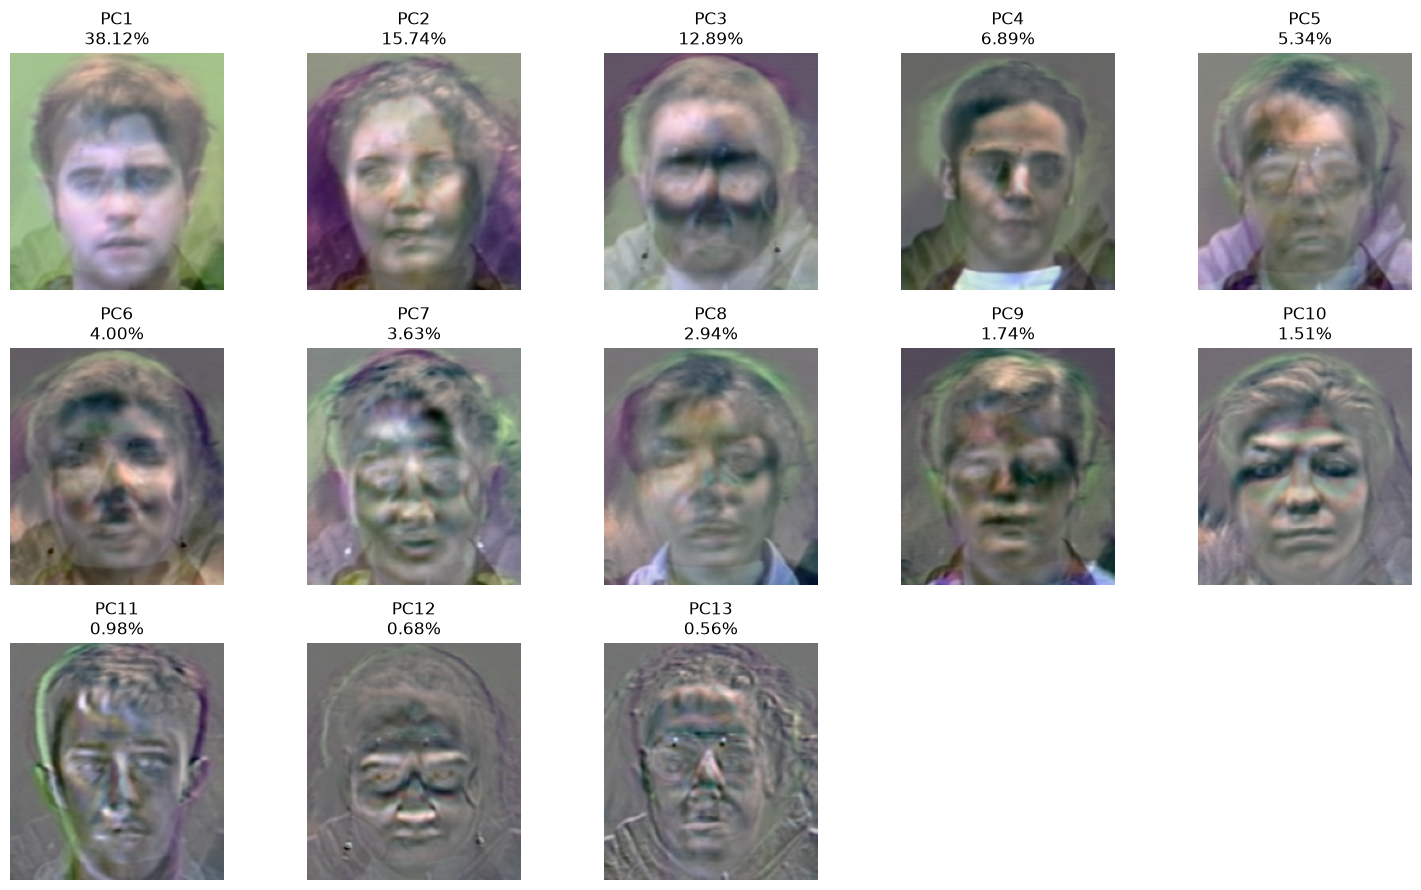

In [75]:
# print("PCA components shape:", pca_95.components_.shape)

image_shape = images[0].shape

print("单张图片 shape:", image_shape)

eigenfaces = pca_95.components_.reshape(
    (pca_95.n_components_,) + image_shape
)

print("特征脸 shape:", eigenfaces.shape)

# eigenface = eigenfaces[0]

# eigenface_show = (
#     eigenface - eigenface.min()
# ) / (
#     eigenface.max() - eigenface.min()
# )

# plt.imshow(eigenface_show)

# plt.title("Eigenface 1")
# plt.axis("off")

# plt.show()

n_eigenfaces = pca_95.n_components_

cols = 5
rows = int(np.ceil(n_eigenfaces / cols))

plt.figure(figsize=(15, 3 * rows))

for i in range(n_eigenfaces):

    eigenface = eigenfaces[i]

    eigenface_show = (
        eigenface - eigenface.min()
    ) / (
        eigenface.max() - eigenface.min()
    )

    plt.subplot(rows, cols, i + 1)

    plt.imshow(eigenface_show)

    plt.title(
        f"PC{i+1}\n"
        f"{pca_95.explained_variance_ratio_[i]*100:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

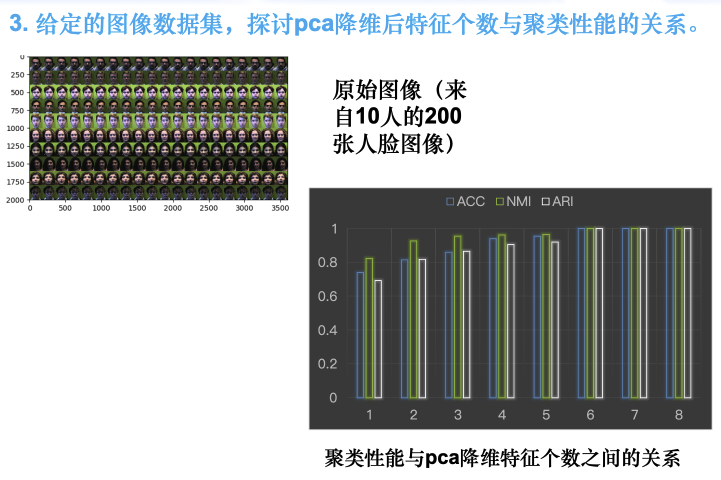

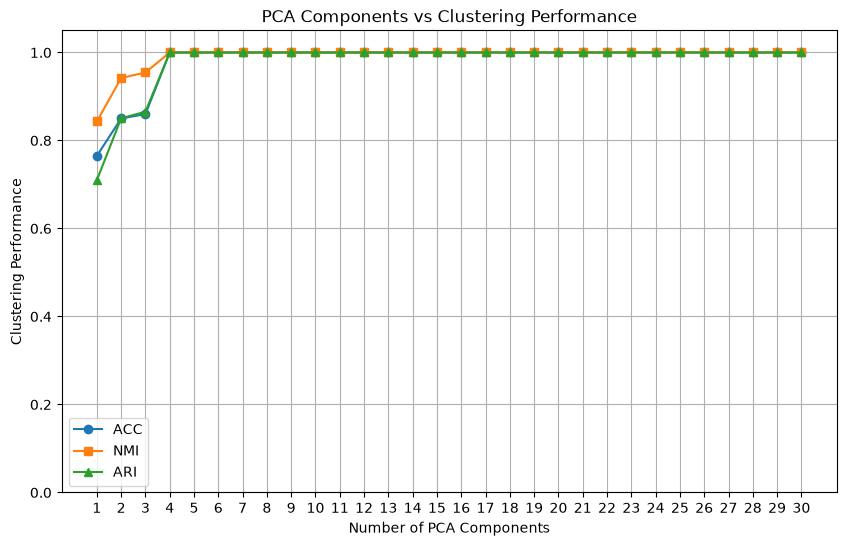

In [76]:
from sklearn.decomposition import PCA

pca_test = PCA(
    n_components=30,
    svd_solver="randomized",
    random_state=42
)

X_pca_30 = pca_test.fit_transform(X)

# print("原始数据：", X.shape)
# print("PCA后：", X_pca_30.shape)

component_numbers = []
acc_scores = []
nmi_scores = []
ari_scores = []


for k in range(1, 31):

    # 取前 k 个主成分
    X_k = X_pca_30[:, :k]

    # KMeans
    kmeans = KMeans(
        n_clusters=10,
        random_state=42,
        n_init=20
    )

    y_pred = kmeans.fit_predict(X_k)

    # 计算聚类性能
    ACC = cluster_acc(labels, y_pred)

    NMI = metrics.normalized_mutual_info_score(
        labels,
        y_pred
    )

    ARI = metrics.adjusted_rand_score(
        labels,
        y_pred
    )

    # 保存结果
    component_numbers.append(k)
    acc_scores.append(ACC)
    nmi_scores.append(NMI)
    ari_scores.append(ARI)

    # print(
    #     "k =", k,
    #     "ACC =", round(ACC, 4),
    #     "NMI =", round(NMI, 4),
    #     "ARI =", round(ARI, 4)
    # )
    
    
    
plt.figure(figsize=(10, 6))

plt.plot(
    component_numbers,
    acc_scores,
    marker="o",
    label="ACC"
)

plt.plot(
    component_numbers,
    nmi_scores,
    marker="s",
    label="NMI"
)

plt.plot(
    component_numbers,
    ari_scores,
    marker="^",
    label="ARI"
)

plt.xlabel("Number of PCA Components")
plt.ylabel("Clustering Performance")

plt.title(
    "PCA Components vs Clustering Performance"
)

plt.xticks(range(1, 31))
plt.ylim(0, 1.05)

plt.grid()
plt.legend()

plt.show()    